0707 results:
- compare new ngram vs old ngram, both proteins, level=4

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.lines as mlines
import os
import matplotlib.patches as mpatches
import sys
from rdkit import DataStructs
from rdkit.Chem import MACCSkeys
from rdkit.Chem import Draw
from rdkit import Chem
from rdkit.Chem.rdmolfiles import MolToSmarts, MolFromSmiles, MolFromSmarts

parent_dir = "/Users/yalilyu/Desktop/result/"
sys.path.append(parent_dir)

from utils.lipinskiness import lipinskiness

In [2]:
db_toadd = {}
db = {}

for protein in ['ar','her2']:
    for i in [1,2,3]:
        key = f"{protein}_l4_r{i}"
        file_path = f"newngram/{protein}_l4_r{i}.csv"
        
        if os.path.exists(file_path):
            print(file_path)
            db_toadd[key] = pd.read_csv(file_path, sep="\s+", header=None)
            db_toadd[key].columns = ["time","smiles", "lip_sc", "docking_sc"]
            db_toadd[key].index = range(1, len(db_toadd[key]) +1)
        else:
            continue

for protein in ['ar','her2']:
        key = f"{protein}"
        key1 = f"{protein}_l4_r1"
        key2 = f"{protein}_l4_r2"
        key3 = f"{protein}_l4_r3"
        if key1 in db_toadd and key2 in db_toadd:
            db[key] = pd.concat([db_toadd[key1], db_toadd[key2], db_toadd[key3]], axis=0)
        elif key1 in db_toadd:
            db[key] = db_toadd[key1]
        elif key2 in db_toadd:
            db[key] = db_toadd[key2]
        elif key3 in db_toadd:
            db[key] = db_toadd[key3]
        else:
            print(f"Neither {key1} nor {key2} nor {key3} found.")

newngram/ar_l4_r1.csv
newngram/ar_l4_r2.csv
newngram/ar_l4_r3.csv
newngram/her2_l4_r1.csv
newngram/her2_l4_r2.csv
newngram/her2_l4_r3.csv


In [3]:
fda_toadd = {}
fda = {}

for protein in ['ar','her2']:
    for i in [1,2]:
        key = f"{protein}_l4_r{i}"
        file_path = f"oldngram/CN_{protein}_l4_r{i}.csv"
        
        if os.path.exists(file_path):
            print(file_path)
            fda_toadd[key] = pd.read_csv(file_path, sep="\s+", header=None)
            fda_toadd[key].columns = ["time","smiles", "lip_sc", "docking_sc"]
            fda_toadd[key].index = range(1, len(fda_toadd[key]) +1)
        else:
            continue

for protein in ['ar','her2']:
        key = f"{protein}"
        key1 = f"{protein}_l4_r1"
        key2 = f"{protein}_l4_r2"
        if key1 in fda_toadd and key2 in fda_toadd:
            fda[key] = pd.concat([fda_toadd[key1], fda_toadd[key2]], axis=0)
        elif key1 in fda_toadd:
            fda[key] = fda_toadd[key1]
        elif key2 in fda_toadd:
            fda[key] = fda_toadd[key2]
        else:
            print(f"Neither {key1} nor {key2} found.")

oldngram/CN_ar_l4_r1.csv
oldngram/CN_ar_l4_r2.csv
oldngram/CN_her2_l4_r1.csv
oldngram/CN_her2_l4_r2.csv


In [4]:
for key, df in db.items():
    db[key] = df[(df['lip_sc'] != -2.0) & (df['docking_sc']!= 1000.0)]

In [5]:
for level, df in db.items():
    num_mol = len(df)
    print(f"Number of molecules generated by db ngram {level} is {num_mol}")

Number of molecules generated by db ngram ar is 1210
Number of molecules generated by db ngram her2 is 1000


In [6]:
for key in ['ar','her2']:
    # Sample 1000 random rows without replacement
    sample_df_db = db[key].sample(n=1000, random_state=28).reset_index(drop=True)
    sample_df_fda = fda[key].sample(n=1000, random_state=28).reset_index(drop=True)
    
    # Assign back to the original dictionaries
    db[key] = sample_df_db
    fda[key] = sample_df_fda

In [7]:
for key, df in fda.items():
    fda[key] = df[(df['lip_sc'] != -2.0) & (df['docking_sc']!= 1000.0)]

In [8]:
for level, df in fda.items():
    num_mol = len(df)
    print(f"Number of molecules generated by fda ngram {level} is {num_mol}")

Number of molecules generated by fda ngram ar is 1000
Number of molecules generated by fda ngram her2 is 1000


dict_values([2.0, 2.0, 2.0])
Highest Tanimoto similarity score (AR): 0.597


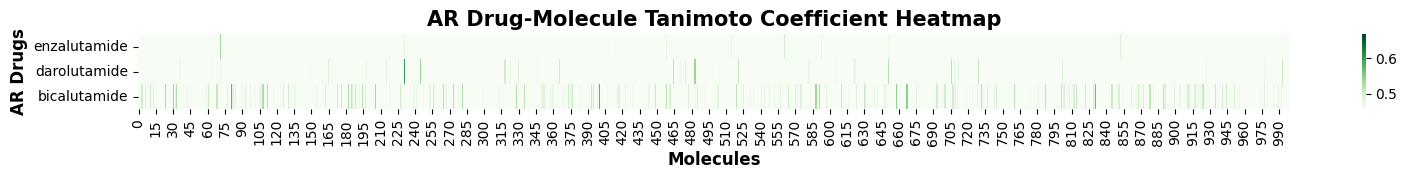

Average Tanimoto score for AR-targeting molecules: 0.415
Std Dev: 0.070


In [9]:
ar_smiles = db['ar'].smiles.to_list()

ar_drug_name = ['enzalutamide', 'darolutamide', 'bicalutamide']

ar_drug_dir = {'enzalutamide':'CC1(C(=O)N(C(=S)N1C2=CC(=C(C=C2)C(=O)NC)F)C3=CC(=C(C=C3)C#N)C(F)(F)F)C', 
               'darolutamide': 'CC(CN1C=CC(=N1)C2=CC(=C(C=C2)C#N)Cl)NC(=O)C3=NNC(=C3)C(C)O', 
               'bicalutamide': 'CC(CS(=O)(=O)C1=CC=C(C=C1)F)(C(=O)NC2=CC(=C(C=C2)C#N)C(F)(F)F)O'}

ar_drug_dock = {'enzalutamide': -6.8, 
               'darolutamide': -8.5, 
               'bicalutamide': -9.8}

ar_drug_lip = {}
for key, smiles in ar_drug_dir.items():
    lip_sc = lipinskiness(smiles)
    ar_drug_lip[key] = lip_sc
print(ar_drug_lip.values())

# Convert SMILES to molecules and fingerprints
ar_drugs = [Chem.MolFromSmiles(smile) for smile in ar_drug_dir.values()]
ar_drug_fps = [MACCSkeys.GenMACCSKeys(mol) for mol in ar_drugs]

ar_mols = [Chem.MolFromSmiles(smile) for smile in ar_smiles]
ar_mol_fps = [MACCSkeys.GenMACCSKeys(mol) for mol in ar_mols]

# Calculate similarity matrix
similarity_matrix_ar = np.zeros((len(ar_drugs), len(ar_mols)))
for i in range(len(ar_drugs)):
    for j in range(len(ar_mols)):
        score = DataStructs.TanimotoSimilarity(ar_drug_fps[i], ar_mol_fps[j])
        similarity_matrix_ar[i, j] = score

# Max similarity score
max_score_ar = np.max(similarity_matrix_ar)
print(f"Highest Tanimoto similarity score (AR): {max_score_ar:.3f}")

# Plot heatmap for AR
plt.figure(figsize=(16, 1))
sns.heatmap(similarity_matrix_ar, annot=False, fmt=".2f", cmap='Greens', vmin=0.457, vmax=0.667,
            yticklabels=[f'{key}' for key in ar_drug_dir.keys()])
plt.xlabel('Molecules', fontsize=12, fontweight='bold')
plt.ylabel('AR Drugs', fontsize=12, fontweight='bold')
plt.title('AR Drug-Molecule Tanimoto Coefficient Heatmap', fontsize=15, fontweight='bold')
plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.2)
plt.show()

# Compute maximum similarity scores for each molecule
ar_tani_score = []
for i in range(len(ar_mols)):
    score = 0
    for j in range(len(ar_drugs)):
        tani_score = DataStructs.TanimotoSimilarity(ar_drug_fps[j], ar_mol_fps[i])
        if tani_score > score:
            score = tani_score
    ar_tani_score.append(score)
ar_tani_score = np.array(ar_tani_score)
print(f"Average Tanimoto score for AR-targeting molecules: {ar_tani_score.mean():.3f}")
print(f"Std Dev: {ar_tani_score.std():.3f}")

dict_values([2.0, 2.0, 1.8])
Highest tanimoto similarity score: 0.656
Average Tanimoto score for HER2-targeting molecules: 0.5024416887160734, 
std: 0.065


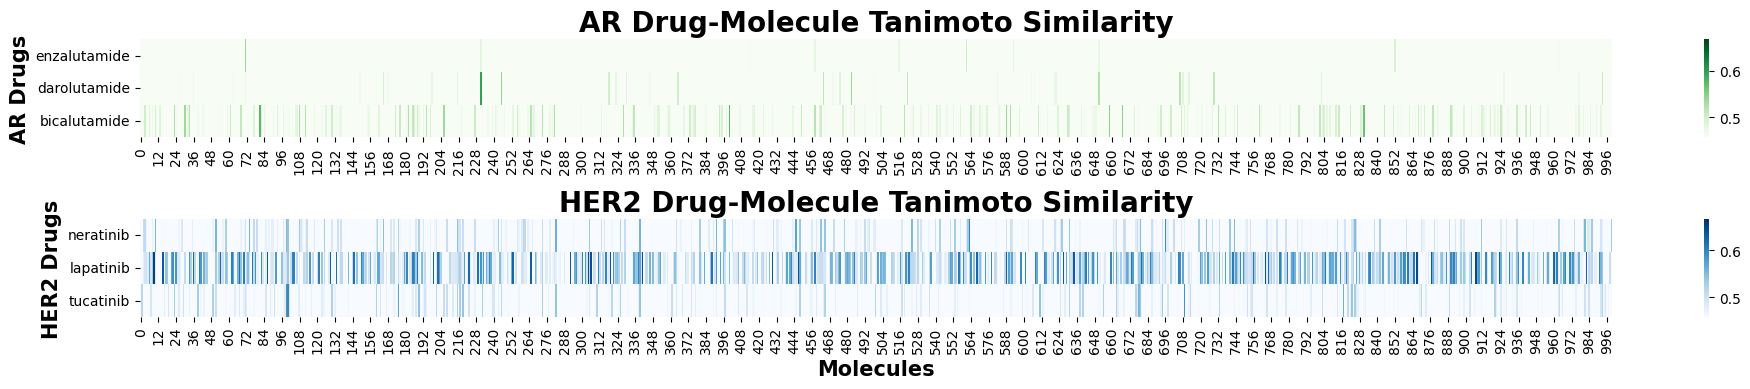

In [10]:
her2_smiles = db['her2'].smiles.to_list()
her2_drug_dir = {'neratinib':'CCOC1=C(C=C2C(=C1)N=CC(=C2NC3=CC(=C(C=C3)OCC4=CC=CC=N4)Cl)C#N)NC(=O)C=CCN(C)C', 
               'lapatinib': 'CS(=O)(=O)CCNCC1=CC=C(O1)C2=CC3=C(C=C2)N=CN=C3NC4=CC(=C(C=C4)OCC5=CC(=CC=C5)F)Cl', 
               'tucatinib': 'CC1=C(C=CC(=C1)NC2=NC=NC3=C2C=C(C=C3)NC4=NC(CO4)(C)C)OC5=CC6=NC=NN6C=C5'}

her2_drug_name= her2_drug_dir.keys()
her2_drug_dock = {'neratinib': -8.5, 
               'lapatinib': -9.7, 
               'tucatinib': -10.6}


her2_drug_lip = {}
for key, values in her2_drug_dir.items():
    lip_sc = lipinskiness(values)
    her2_drug_lip[key] = lip_sc
print(her2_drug_lip.values())


her2_drugs = [Chem.MolFromSmiles(drug) for drug in her2_drug_dir.values()]
her2_drug_fps = [ MACCSkeys.GenMACCSKeys(x) for x in her2_drugs]
her2_mols = [Chem.MolFromSmiles(smile) for smile in her2_smiles]
her2_mol_fps = [ MACCSkeys.GenMACCSKeys(x) for x in her2_mols]

similarity_matrix = np.zeros((len(her2_drugs), len(her2_mols)))

# Calculate similarity scores
for i in range(len(her2_drugs)):
    for j in range(len(her2_mols)):
        score = DataStructs.TanimotoSimilarity(her2_drug_fps[i], her2_mol_fps[j])
        similarity_matrix[i, j] = score
max_score = np.max(similarity_matrix)
print(f"Highest tanimoto similarity score: {max_score:.3f}")


her2_tani_score = []
for i in range(len(her2_mols)):
    score = 0
    for j in range(len(her2_drugs)):
        tani_score = DataStructs.TanimotoSimilarity(her2_drug_fps[j], her2_mol_fps[i])
        if tani_score > score:
            score = tani_score
    her2_tani_score.append(score)
her2_tani_score = np.array(her2_tani_score)
print(f"Average Tanimoto score for HER2-targeting molecules: {her2_tani_score.mean()}, \nstd: {her2_tani_score.std():.3f}")

fig, axes = plt.subplots(2,1, figsize=(20, 4))

# ----------- AR section -----------
# Assume all AR data steps are done: similarity matrix, max score, etc.

# AR heatmap
sns.heatmap(similarity_matrix_ar, ax=axes[0], annot=False, fmt=".2f", cmap='Greens', vmin=0.457, vmax=0.667,
            yticklabels=list(ar_drug_dir.keys()))
axes[0].set_title('AR Drug-Molecule Tanimoto Similarity', fontsize=20, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('AR Drugs', fontweight='bold',fontsize=15)

sns.heatmap(similarity_matrix, ax=axes[1], annot=False, fmt=".2f", cmap='Blues', vmin=0.457, vmax=0.667,
            yticklabels=[f'{list(her2_drug_dir.keys())[i]}' for i in range(len(her2_drug_dir))])
axes[1].set_title('HER2 Drug-Molecule Tanimoto Similarity', fontsize=20, fontweight='bold')
axes[1].set_xlabel('Molecules', fontweight='bold',fontsize=15)
axes[1].set_ylabel('HER2 Drugs', fontweight='bold',fontsize=15)


# Adjust layout
plt.tight_layout()
plt.show()

In [11]:
db['ar']['tani'] = ar_tani_score
db['her2']['tani'] = her2_tani_score

In [12]:
db['ar'] = db['ar'].drop_duplicates(subset='smiles')
db['her2'] = db['her2'].drop_duplicates(subset='smiles')

print(len(db['ar']), len(db['her2']))

969 984


In [13]:
best_three_tani = {}
for protein in ['ar','her2']:
    best_three_tani[protein] = db[protein].nlargest(3,'tani')


In [14]:
best_three_tani['ar']

,time,smiles,lip_sc,docking_sc,tani
231,1.750935e+09,C(C)CC1=N(NC(=O)N1C2C(C(Cl)C(C)C3=C(C(C)C=C32)...,1.545455,-7.700,0.597403
81,1.723722e+09,C(C(O)COC=O)NS(=O)(=O)S(=O)(=O)S(=O)(=O)C(F)(F...,1.173563,-6.441,0.575342
400,1.733846e+09,C(CC)(ONC(F)(F)(F))NS(=O)S(=O)(=O)S(=O)(=O)C(F...,1.000000,-7.050,0.575342


In [15]:
ar_best_three_tani = best_three_tani['ar'].smiles.to_list()

In [16]:
best_three_tani['her2']

,time,smiles,lip_sc,docking_sc,tani
9,1.743818e+09,C(CCO)NC1=C(C2N(C(C)C(C2(C3C(CCC(S(=O)(=O)3))C...,0.997479,-8.6,0.655914
907,1.751199e+09,C(Cl)OCOC1=C(C=NC1=S)NC2=N(C3=C(C=C(C)C(O)3S(=...,2.000000,-8.5,0.648936
867,1.743898e+09,C(CCO)NC1=C(C2N(C(C)C(C2C(O1)NC(F)(F)(F))S(=O)...,1.148571,-8.4,0.645833


In [31]:
her2_best_three_tani = best_three_tani['her2'].smiles.to_list()
her2_best_three_tani[0]

'C(CCO)NC1=C(C2N(C(C)C(C2(C3C(CCC(S(=O)(=O)3))C(F)(F)(F))S(=O)(=O)(C(F)(F)(F)))Cl)C=C1CCCCC4=C(NCCC4))'

In [18]:
best_three_dock = {}
for protein in ['ar','her2']:
    best_three_dock[protein] = db[protein].nsmallest(3,'docking_sc')

In [19]:
best_three_dock['ar']

,time,smiles,lip_sc,docking_sc,tani
598,1.721783e+09,C(C1O(N=NSC2C(=CNC21O(C(F)(F)(F)))C(F)(F)(F)))...,1.587356,-9.528,0.353659
152,1.751122e+09,C(S(=O)(=O)Cl)1(CC(F)(F)(C2=C(CC=NN2N1(C(F)(F)...,1.400000,-9.500,0.382716
565,1.751122e+09,C(S(=O)(=O)Cl)1(CC(F)(F)(C2=C(CC=NN2N1(C(F)(F)...,1.387097,-9.400,0.431818


In [20]:
ar_best_three_dock = best_three_dock['ar'].smiles.to_list()

In [21]:
best_three_dock['her2']

,time,smiles,lip_sc,docking_sc,tani
332,1.721840e+09,C(C1=C(N(C2=C(CC(=O)N(CC2(C1CC3(C4=C(C=CC=C4CC...,1.774194,-11.42,0.439024
27,1.721844e+09,C(C)C(SC1C(=CC=C(O)N1CC(=O)NS(=O)(=O)Cl)OC)C(=...,1.532485,-11.28,0.471698
198,1.723710e+09,C(C1S(N(C(=O)O)CN1CC2=C(C=CC=C2C3=C(CCC(C=C3C4...,1.685714,-11.20,0.401961


In [22]:
her2_best_three_dock = best_three_dock['her2'].smiles.to_list()

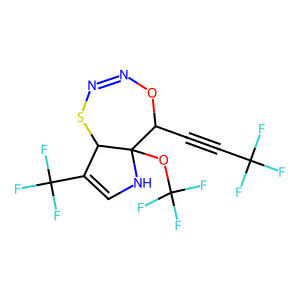

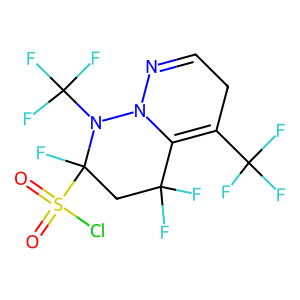

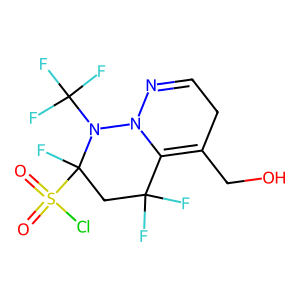

In [23]:
for smiles in ar_best_three_dock:
    mol = MolFromSmiles(smiles)
    display(Draw.MolToImage(mol))

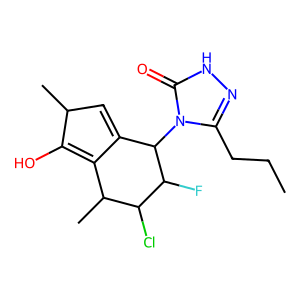

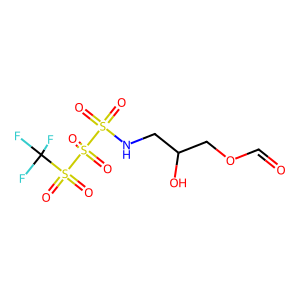

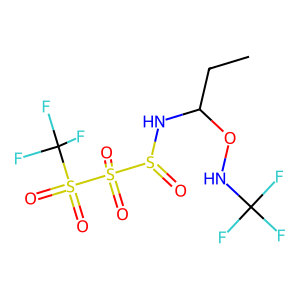

In [24]:
for smiles in ar_best_three_tani:
    mol = MolFromSmiles(smiles)
    display(Draw.MolToImage(mol))

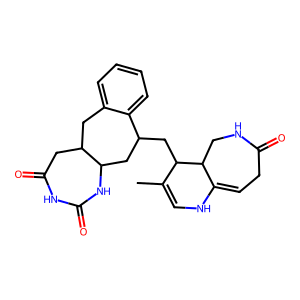

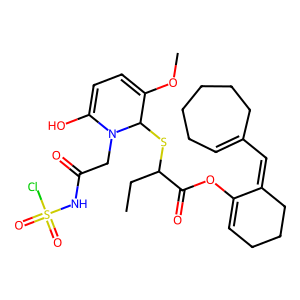

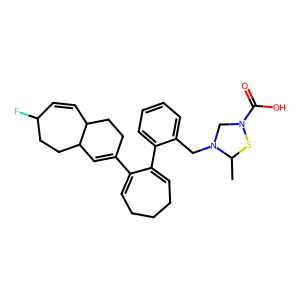

In [25]:
for smiles in her2_best_three_dock:
    mol = MolFromSmiles(smiles)
    display(Draw.MolToImage(mol))

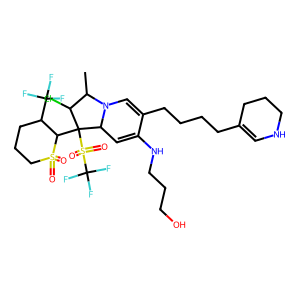

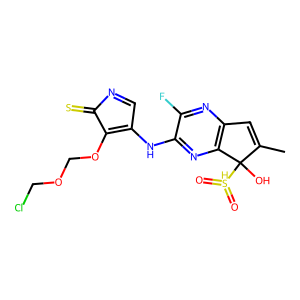

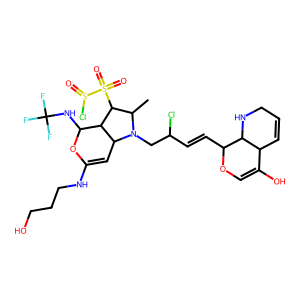

In [26]:
for smiles in her2_best_three_tani:
    mol = MolFromSmiles(smiles)
    display(Draw.MolToImage(mol))

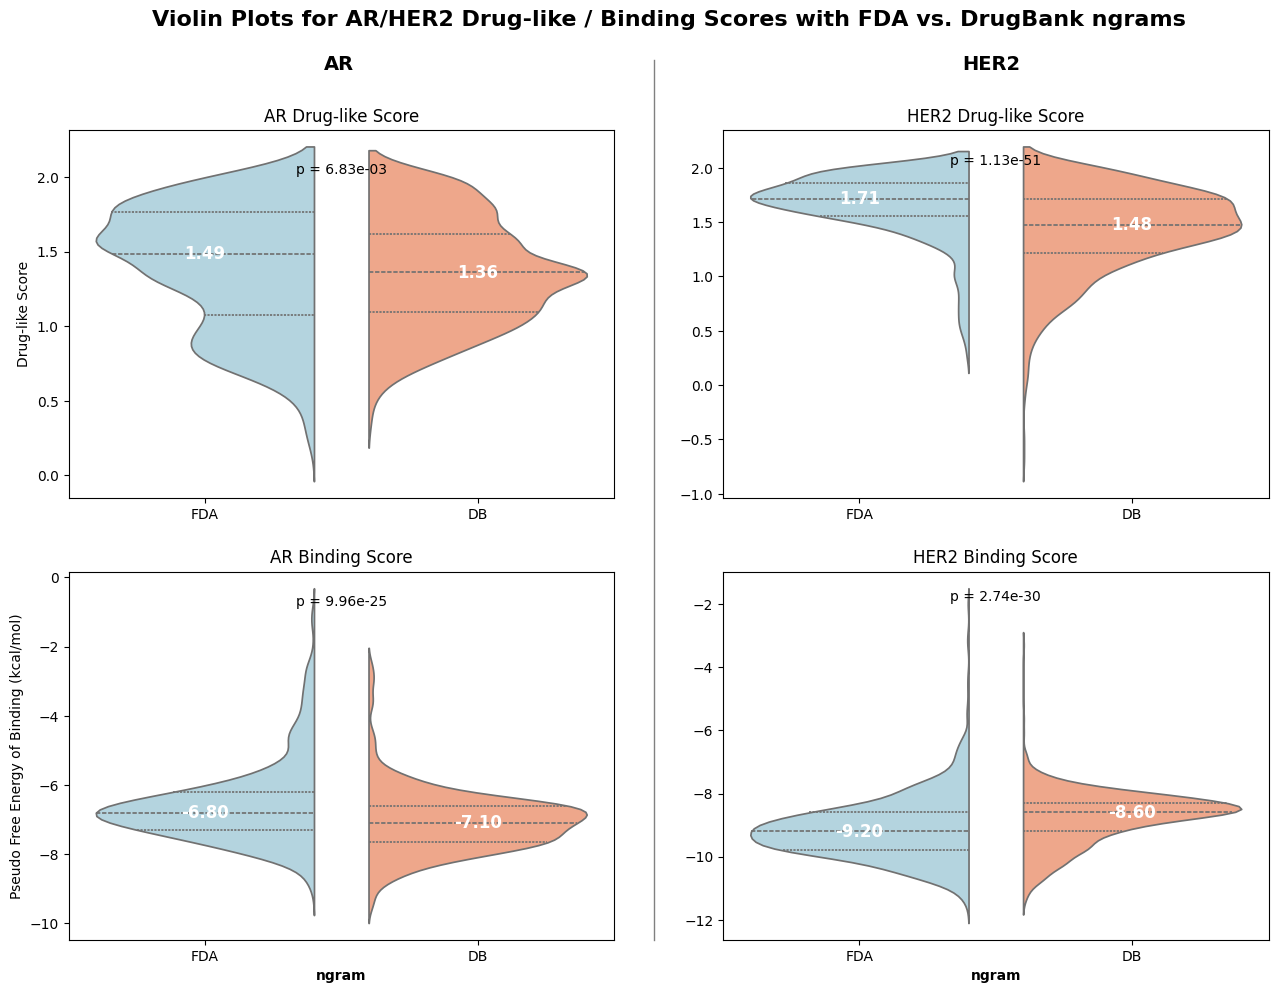

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.patch.set_facecolor('white')  # Set figure background to white

def annotate_medians(ax, data, y_col):
    medians = data.groupby('source')[y_col].median()
    for i, source in enumerate(['FDA', 'DB']):
        median_value = medians.get(source, None)
        if median_value is not None:
            ax.text(
                i, median_value, f'{median_value:.2f}', 
                va='center', ha='center', color='white', fontweight='bold', fontsize=12
            )

datasets = [
    ('AR Lipinski Score', fda['ar'][['lip_sc']], db['ar'][['lip_sc']], 'lip_sc'),
    ('AR Docking Score', fda['ar'][['docking_sc']], db['ar'][['docking_sc']], 'docking_sc'),
    ('HER2 Lipinski Score', fda['her2'][['lip_sc']], db['her2'][['lip_sc']], 'lip_sc'),
    ('HER2 Docking Score', fda['her2'][['docking_sc']], db['her2'][['docking_sc']], 'docking_sc')
]

titles = [
    "AR Drug-like Score",
    "AR Binding Score",
    "HER2 Drug-like Score",
    "HER2 Binding Score"
]

# Positions to swap
positions = [
    (0, 0), (1, 0), (0, 1), (1, 1)
]

for idx, (label, df_fda, df_db, metric) in enumerate(datasets):
    row, col = positions[idx]
    combined_df = pd.concat([
        df_fda.assign(source='FDA'),
        df_db.assign(source='DB')
    ])
    ax = axes[row, col]
    # Set the palette for specific colors
    palette = {
        'FDA': 'lightblue',
        'DB': 'lightsalmon'
    }
    sns.violinplot(
        x='source', y=metric, hue='source', data=combined_df,
        split=True, inner='quart', ax=ax, palette=palette
    )
    ax.set_title(titles[idx])
    # annotate medians
    annotate_medians(ax, combined_df, metric)
    # Mann-Whitney p-value
    fda_vals = combined_df[combined_df['source']=='FDA'][metric].values
    db_vals = combined_df[combined_df['source']=='DB'][metric].values
    stat, pvalue = stats.mannwhitneyu(fda_vals, db_vals, alternative='two-sided')
    ymax = max(combined_df[metric])
    ax.text(0.5, ymax, f'p = {pvalue:.2e}', ha='center', va='bottom', color='black', fontsize=10)

# Set y-labels only for left column plots
for row in range(2):
    for ax in [axes[row, 0]]:
        ax.set_ylabel('Drug-like Score' if row==0 else 'Pseudo Free Energy of Binding (kcal/mol)')
    for ax in [axes[row, 1]]:
        ax.set_ylabel('')

# Remove x labels for top row
for ax in [axes[0, 0], axes[0, 1]]:
    ax.set_xlabel('')

# Set x labels only for bottom row
axes[1, 0].set_xlabel('ngram',fontweight='bold')
axes[1, 1].set_xlabel('ngram',fontweight='bold')

# Add column labels "AR" and "HER2" above columns
fig.text(0.28, 0.92, 'AR', ha='center', fontsize=14, fontweight='bold')
fig.text(0.715, 0.92, 'HER2', ha='center', fontsize=14, fontweight='bold')


# Add overall super title
plt.suptitle("Violin Plots for AR/HER2 Drug-like / Binding Scores with FDA vs. DrugBank ngrams", fontsize=16,fontweight='bold')

plt.subplots_adjust(left=0.1, right=0.9, top=0.86, bottom=0.05, hspace=0.2)
import matplotlib.lines as mlines
line = mlines.Line2D([0.49, 0.49], [0.05, 0.93], transform=plt.gcf().transFigure,
                     color='grey', linewidth=1)
plt.gcf().add_artist(line)

plt.show()


In [28]:
ar_drug_name = ['enzalutamide', 'darolutamide', 'bicalutamide']

ar_drug_smile = {'enzalutamide':'CC1(C(=O)N(C(=S)N1C2=CC(=C(C=C2)C(=O)NC)F)C3=CC(=C(C=C3)C#N)C(F)(F)F)C', 
               'darolutamide': 'CC(CN1C=CC(=N1)C2=CC(=C(C=C2)C#N)Cl)NC(=O)C3=NNC(=C3)C(C)O', 
               'bicalutamide': 'CC(CS(=O)(=O)C1=CC=C(C=C1)F)(C(=O)NC2=CC(=C(C=C2)C#N)C(F)(F)F)O'}

ar_drug_dock = {'enzalutamide': -6.8, 
               'darolutamide': -8.5, 
               'bicalutamide': -9.8}
her2_drug_dir = {'neratinib':'CCOC1=C(C=C2C(=C1)N=CC(=C2NC3=CC(=C(C=C3)OCC4=CC=CC=N4)Cl)C#N)NC(=O)C=CCN(C)C', 
               'lapatinib': 'CS(=O)(=O)CCNCC1=CC=C(O1)C2=CC3=C(C=C2)N=CN=C3NC4=CC(=C(C=C4)OCC5=CC(=CC=C5)F)Cl', 
               'tucatinib': 'CC1=C(C=CC(=C1)NC2=NC=NC3=C2C=C(C=C3)NC4=NC(CO4)(C)C)OC5=CC6=NC=NN6C=C5'}

her2_drug_dock = {'neratinib': -8.5, 
               'lapatinib': -9.7, 
               'tucatinib': -10.6}


her2_drug_lip = {}
for key, values in her2_drug_dir.items():
    lip_sc = lipinskiness(values)
    her2_drug_lip[key] = lip_sc
print(her2_drug_lip.values())

ar_drug_lip = {}
for key, value in ar_drug_smile.items():
    lip_sc = lipinskiness(value)
    ar_drug_lip[key] = lip_sc
print(ar_drug_lip.values())

ar_drug_pts = {drug: (ar_drug_lip[drug], ar_drug_dock[drug]) for drug in ar_drug_lip}

print(ar_drug_pts)

her2_drug_pts = {drug: (her2_drug_lip[drug], her2_drug_dock[drug]) for drug in her2_drug_lip}
print(her2_drug_pts)

dict_values([2.0, 2.0, 1.8])
dict_values([2.0, 2.0, 2.0])
{'enzalutamide': (2.0, -6.8), 'darolutamide': (2.0, -8.5), 'bicalutamide': (2.0, -9.8)}
{'neratinib': (2.0, -8.5), 'lapatinib': (2.0, -9.7), 'tucatinib': (1.8, -10.6)}


/opt/anaconda3/envs/dsmc2/lib/python3.10/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
/opt/anaconda3/envs/dsmc2/lib/python3.10/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
/opt/anaconda3/envs/dsmc2/lib/python3.10/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
/opt/anaconda3/envs/dsmc2/lib/python3.10/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(


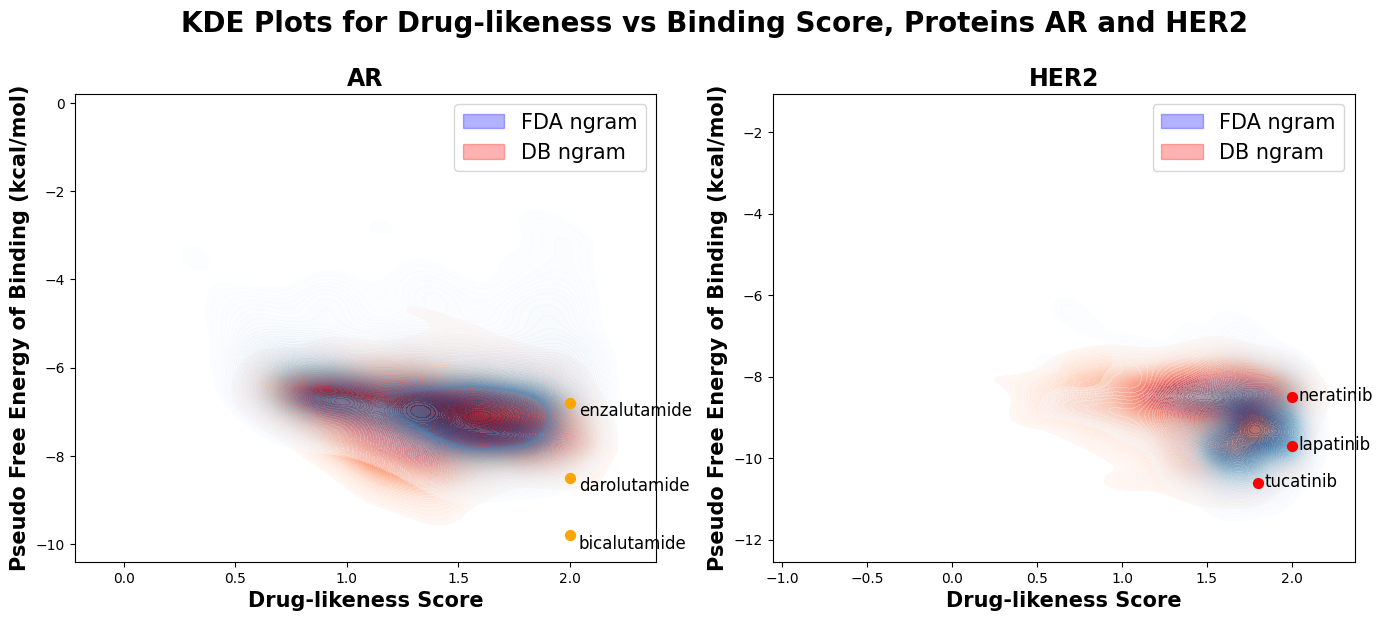

In [29]:
selected_keys = [ 'ar', 'her2']

# Create figure with 2x2 subplots
nrows, ncols = 1, 2
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 6))
axes = axes.flatten()



# Plot density for each key
for i, key in enumerate(selected_keys):
    ax = axes[i]
    if key in db and key in db and key in fda:
        # Data
        x_db = db[key]['lip_sc']
        y_db = db[key]['docking_sc']
        x_fda = fda[key]['lip_sc']
        y_fda = fda[key]['docking_sc']
        sns.kdeplot(x=x_db, y=y_db, fill=True, levels=100, linewidths=0,
                    cmap='Reds', alpha = 0.7, ax=ax, label='DB ngram')
        sns.kdeplot(x=x_fda, y=y_fda, fill=True, levels=100, linewidths=1,
                    cmap='Blues', alpha = 0.3,  ax=ax, label='FDA ngram')


        
        if key.startswith('ar'):
            for drug, (lip, dock) in ar_drug_pts.items():
                ax.scatter(lip,dock,label=drug, s=50, color='orange')
                ax.text(lip + 0.04, dock - 0.3, drug, fontsize=12)

    # Plot points for 'her2' if keys start with 'her2'
        elif key.startswith('her2'):
            for drug, (lip, dock) in her2_drug_pts.items():
                ax.scatter(lip,dock,label=drug, s=50, color='red')
                ax.text(lip + 0.04, dock - 0.1, drug, fontsize=12)

        # sns.scatterplot()
        axes[0].set_title('AR', fontsize=17, fontweight='bold')
        axes[1].set_title('HER2', fontsize=17, fontweight='bold')
        ax.set_xlabel('Drug-likeness Score',fontsize=15, fontweight='bold' )
        ax.set_ylabel('Pseudo Free Energy of Binding (kcal/mol)',fontsize=15, fontweight='bold')
        ax.grid(False)

        # Legends
        # blue_patch = mpatches.Patch(color='blue', alpha=0.5, label='Single')
        red_patch = mpatches.Patch(color='red', alpha=0.3, label='DB ngram')
        blue_patch = mpatches.Patch(color='blue', alpha=0.3, label='FDA ngram')
        ax.legend(handles=[ blue_patch, red_patch], fontsize= 15)
    else:
        ax.set_visible(False)


# Collect axes for 'ar' and 'her2' groups
ar_axes = [ax for key, ax in zip(selected_keys, axes) if key.startswith('ar')]
her2_axes = [ax for key, ax in zip(selected_keys, axes) if key.startswith('her2')]
if ar_axes:
    ar_xlim = (
        min(ax.get_xlim()[0] for ax in ar_axes),
        max(ax.get_xlim()[1] for ax in ar_axes)
    )
    ar_ylim = (
        min(ax.get_ylim()[0] for ax in ar_axes),
        max(ax.get_ylim()[1] for ax in ar_axes)
    )
    


# Compute combined axes limits for 'her2' group
if her2_axes:
    her2_xlim = (
        min(ax.get_xlim()[0] for ax in her2_axes),
        max(ax.get_xlim()[1] for ax in her2_axes)
    )
    her2_ylim = (
        min(ax.get_ylim()[0] for ax in her2_axes),
        max(ax.get_ylim()[1] for ax in her2_axes)
    )
# Set same axes limits for 'ar' plots
if ar_axes:
    for ax in ar_axes:
        ax.set_xlim(*ar_xlim)
        ax.set_ylim(*ar_ylim)

# Set same axes limits for 'her2' plots
if her2_axes:
    for ax in her2_axes:
        ax.set_xlim(*her2_xlim)
        ax.set_ylim(*her2_ylim)

# Adjust layout
fig.suptitle('KDE Plots for Drug-likeness vs Binding Score, Proteins AR and HER2', fontsize=20, fontweight='bold',y=1.02)
plt.subplots_adjust(left=0.1, right=0.9, top=0.88, bottom=0.1, wspace=0.2, hspace=0.3)
plt.show()


In [30]:
her2_best_three_dock[0]

'C(C1=C(N(C2=C(CC(=O)N(CC2(C1CC3(C4=C(C=CC=C4CC5(CC(=O)NC(=O)NC5C3)))))))))'